## Assignment No.13

In [43]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv("diabetes.csv")
print("Shape:", df.shape)
print("\nData Types:\n", df.dtypes)
print("\nFirst 5 Rows:\n", df.head())
print("\nMissing Values:\n", df.isnull().sum())
print("\nDuplicate Rows:", df.duplicated().sum())
print("\nTarget Distribution:\n", df['Outcome'].value_counts())
print("\nSummary Statistics:\n", df.describe())

Shape: (768, 9)

Data Types:
 Pregnancies                   int64
Glucose                       int64
BloodPressure                 int64
SkinThickness                 int64
Insulin                       int64
BMI                         float64
DiabetesPedigreeFunction    float64
Age                           int64
Outcome                       int64
dtype: object

First 5 Rows:
    Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3      

# Histograms & Box Plots

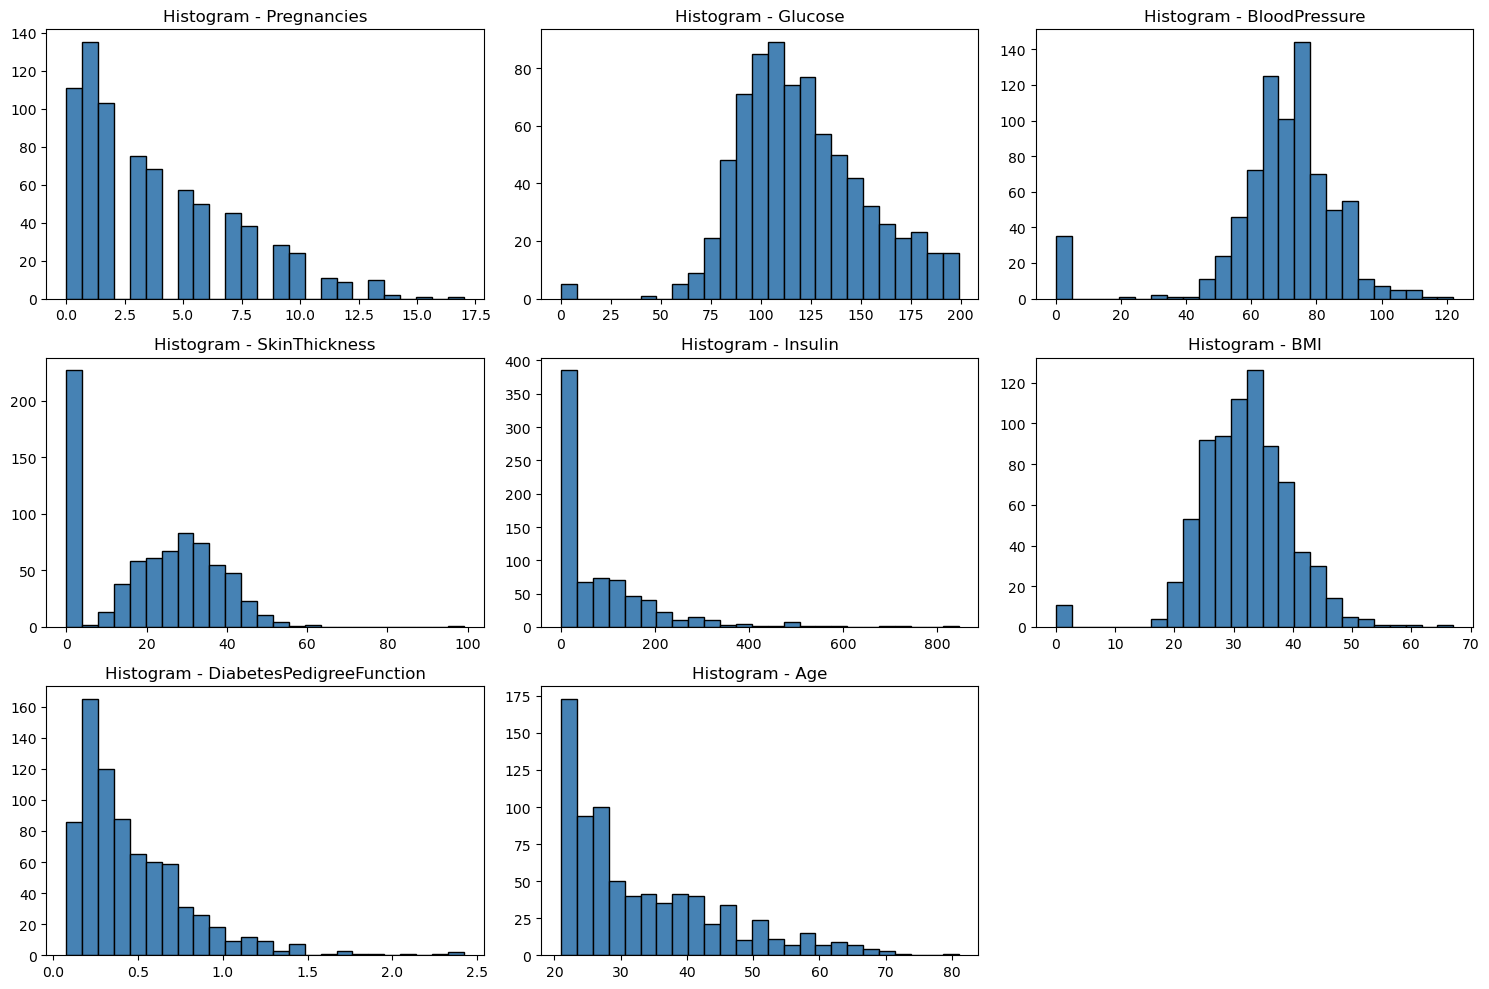

In [44]:
features = df.columns[:-1].tolist()
fig, axes = plt.subplots(3, 3, figsize=(15, 10))
axes = axes.flatten()
for i, col in enumerate(features):
    axes[i].hist(df[col], bins=25, color='steelblue', edgecolor='black')
    axes[i].set_title(f'Histogram - {col}')
axes[-1].set_visible(False)
plt.tight_layout()
plt.savefig('histograms.png')
plt.show()

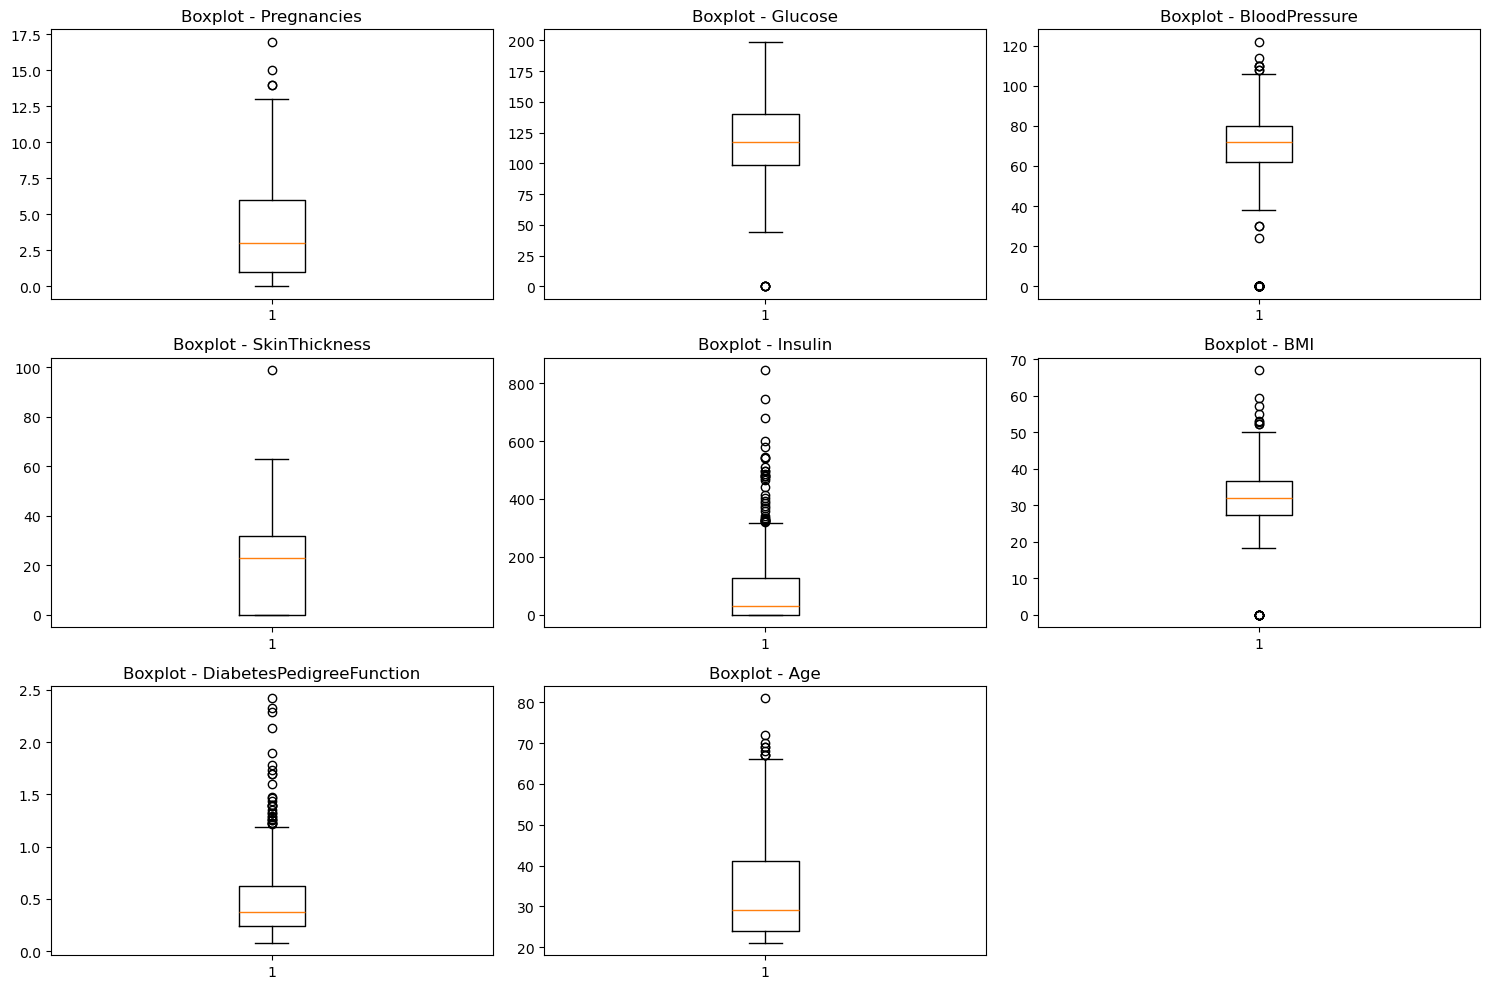

In [45]:
fig, axes = plt.subplots(3, 3, figsize=(15, 10))
axes = axes.flatten()
for i, col in enumerate(features):
    axes[i].boxplot(df[col])
    axes[i].set_title(f'Boxplot - {col}')
axes[-1].set_visible(False)
plt.tight_layout()
plt.savefig('boxplots.png')
plt.show()

# Scatter Plots & Bar Plots

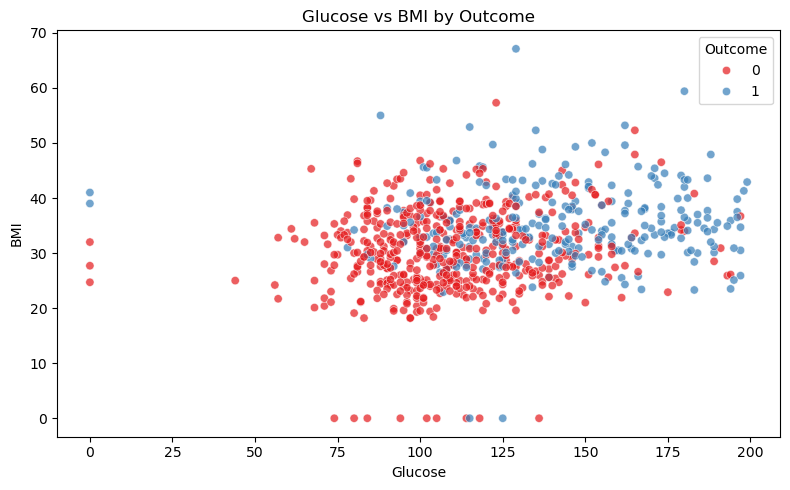

In [46]:
plt.figure(figsize=(8, 5))
sns.scatterplot(x='Glucose', y='BMI', hue='Outcome', data=df, palette='Set1', alpha=0.7)
plt.title('Glucose vs BMI by Outcome')
plt.tight_layout()
plt.savefig('scatter_glucose_bmi.png')
plt.show()

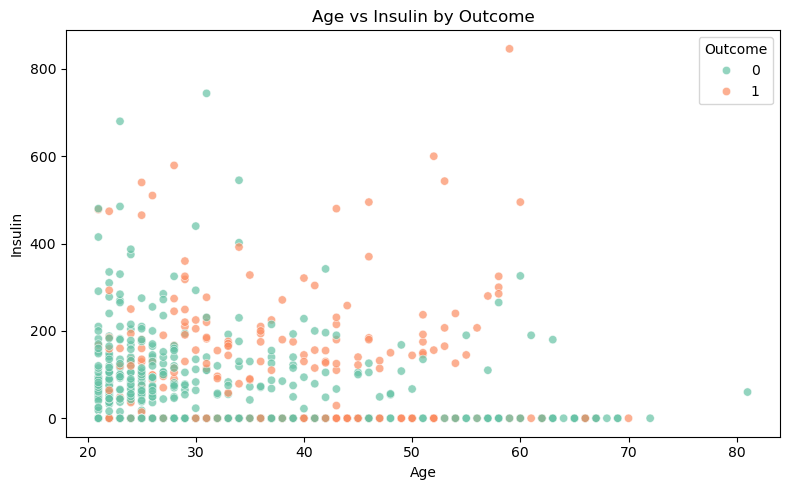

In [47]:
plt.figure(figsize=(8, 5))
sns.scatterplot(x='Age', y='Insulin', hue='Outcome', data=df, palette='Set2', alpha=0.7)
plt.title('Age vs Insulin by Outcome')
plt.tight_layout()
plt.savefig('scatter_age_insulin.png')
plt.show()

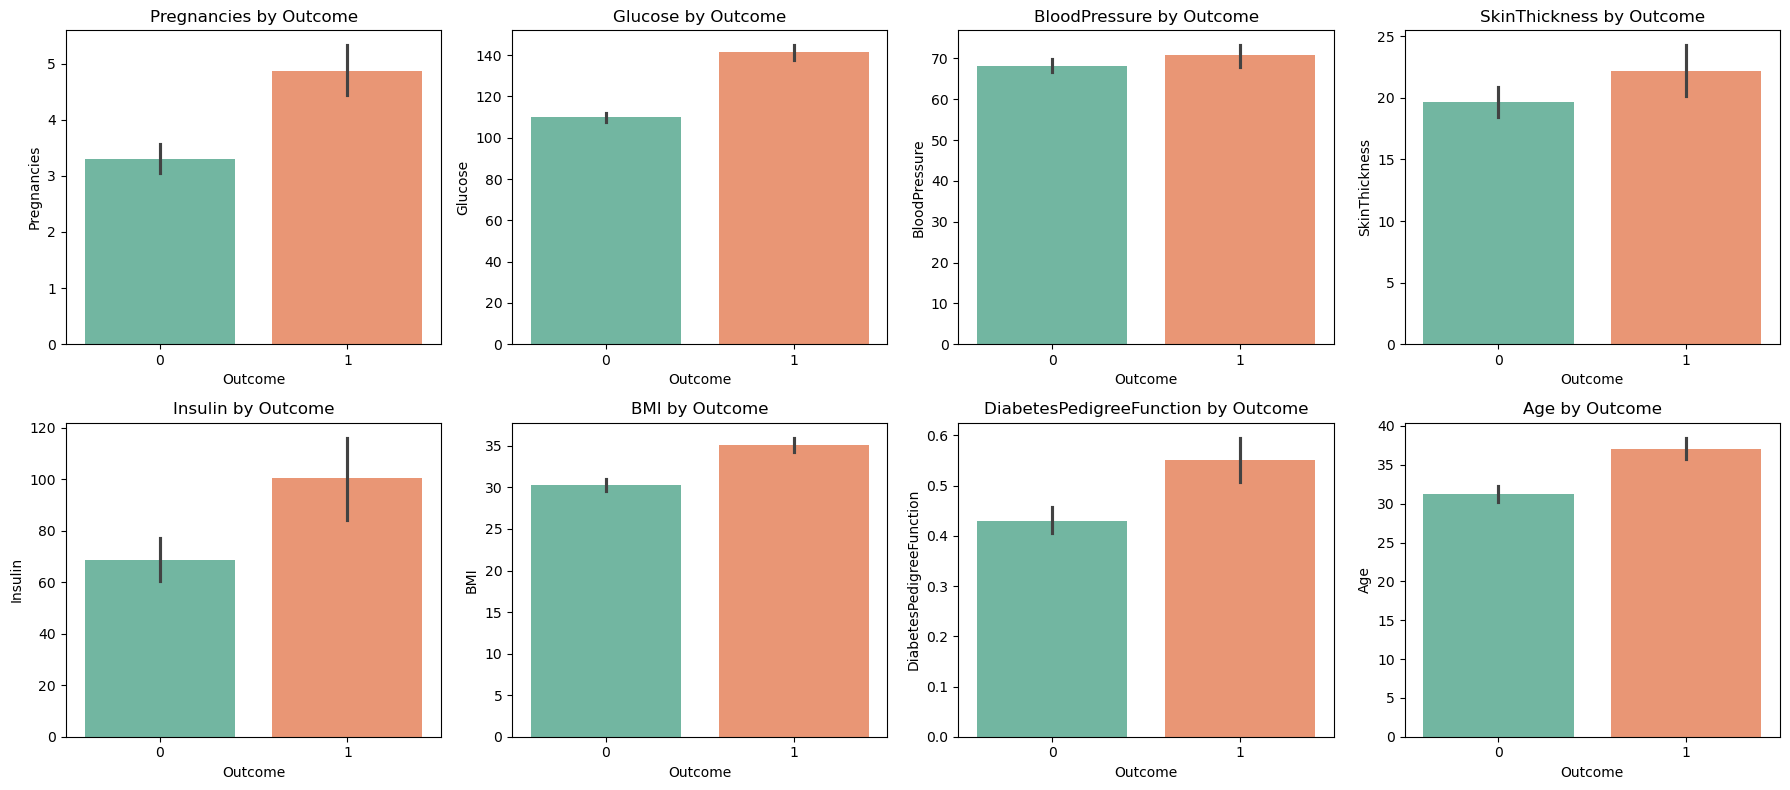

In [48]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()
for i, col in enumerate(features):
    sns.barplot(x='Outcome', y=col, data=df, palette='Set2', ax=axes[i])
    axes[i].set_title(f'{col} by Outcome')
plt.tight_layout()
plt.savefig('barplots_by_outcome.png')
plt.show()

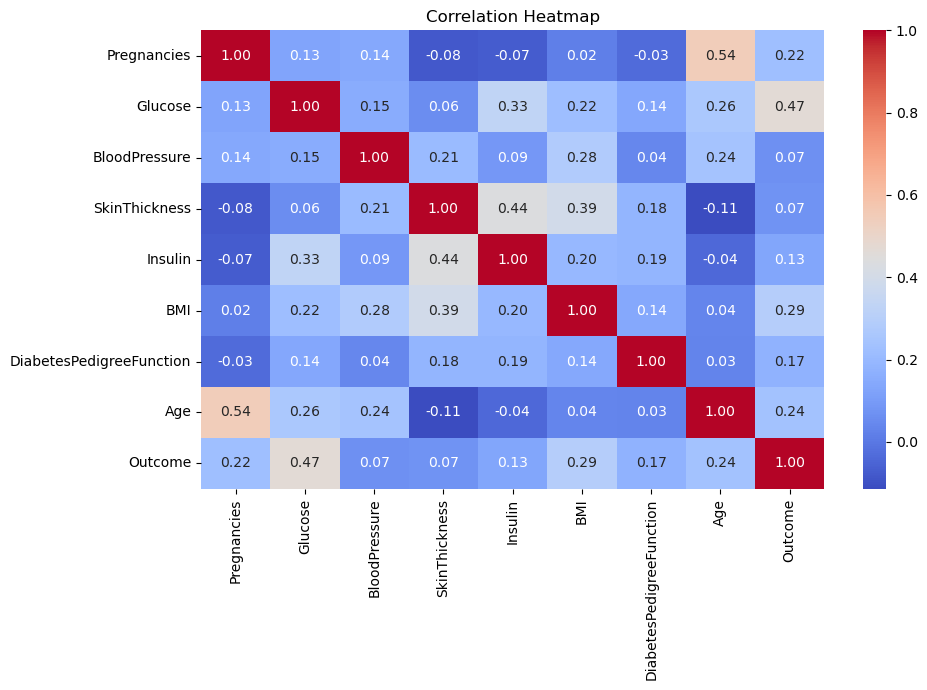

In [49]:
plt.figure(figsize=(10, 7))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.savefig('correlation_heatmap.png')
plt.show()

# Data Preprocessing

In [50]:
#Impute Missing Values
zero_cols = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

for col in zero_cols:
    df[col] = df[col].replace(0, np.nan)

print("Missing values after replacing zeros:\n", df.isnull().sum())

for col in zero_cols:
    df[col] = df[col].fillna(df[col].median())

print("\nMissing values after imputation:\n", df.isnull().sum())

Missing values after replacing zeros:
 Pregnancies                   0
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0
dtype: int64

Missing values after imputation:
 Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


In [51]:
#Encoding & Scaling
from sklearn.preprocessing import StandardScaler

print("No categorical variables found - all features are numerical.")

X = df.drop('Outcome', axis=1)
y = df['Outcome']

scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)
print(X_scaled.head())

No categorical variables found - all features are numerical.
   Pregnancies   Glucose  BloodPressure  SkinThickness   Insulin       BMI  \
0     0.639947  0.866045      -0.031990       0.670643 -0.181541  0.166619   
1    -0.844885 -1.205066      -0.528319      -0.012301 -0.181541 -0.852200   
2     1.233880  2.016662      -0.693761      -0.012301 -0.181541 -1.332500   
3    -0.844885 -1.073567      -0.528319      -0.695245 -0.540642 -0.633881   
4    -1.141852  0.504422      -2.679076       0.670643  0.316566  1.549303   

   DiabetesPedigreeFunction       Age  
0                  0.468492  1.425995  
1                 -0.365061 -0.190672  
2                  0.604397 -0.105584  
3                 -0.920763 -1.041549  
4                  5.484909 -0.020496  


In [52]:
#Train-Test Split
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, roc_auc_score, classification_report,
                              confusion_matrix)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)
print("Train:", X_train.shape, "| Test:", X_test.shape)

Train: (614, 8) | Test: (154, 8)


In [53]:
#LightGBM & XGBoost
from lightgbm import LGBMClassifier

lgbm_model = LGBMClassifier(n_estimators=100, random_state=42, verbose=-1)
lgbm_model.fit(X_train, y_train)
y_pred_lgbm = lgbm_model.predict(X_test)
y_prob_lgbm = lgbm_model.predict_proba(X_test)[:, 1]

print("LightGBM Performance:")
print("Accuracy :", round(accuracy_score(y_test, y_pred_lgbm), 4))
print("Precision:", round(precision_score(y_test, y_pred_lgbm), 4))
print("Recall   :", round(recall_score(y_test, y_pred_lgbm), 4))
print("F1-Score :", round(f1_score(y_test, y_pred_lgbm), 4))
print("ROC-AUC  :", round(roc_auc_score(y_test, y_prob_lgbm), 4))
print("\nClassification Report:\n", classification_report(y_test, y_pred_lgbm))

LightGBM Performance:
Accuracy : 0.7273
Precision: 0.62
Recall   : 0.5741
F1-Score : 0.5962
ROC-AUC  : 0.8172

Classification Report:
               precision    recall  f1-score   support

           0       0.78      0.81      0.79       100
           1       0.62      0.57      0.60        54

    accuracy                           0.73       154
   macro avg       0.70      0.69      0.70       154
weighted avg       0.72      0.73      0.72       154



In [54]:
#XGBoost
from xgboost import XGBClassifier

xgb_model = XGBClassifier(n_estimators=100, random_state=42,
                           use_label_encoder=False, eval_metric='logloss')
xgb_model.fit(X_train, y_train)
y_pred_xgb = xgb_model.predict(X_test)
y_prob_xgb = xgb_model.predict_proba(X_test)[:, 1]

print("XGBoost Performance:")
print("Accuracy :", round(accuracy_score(y_test, y_pred_xgb), 4))
print("Precision:", round(precision_score(y_test, y_pred_xgb), 4))
print("Recall   :", round(recall_score(y_test, y_pred_xgb), 4))
print("F1-Score :", round(f1_score(y_test, y_pred_xgb), 4))
print("ROC-AUC  :", round(roc_auc_score(y_test, y_prob_xgb), 4))
print("\nClassification Report:\n", classification_report(y_test, y_pred_xgb))

XGBoost Performance:
Accuracy : 0.7597
Precision: 0.6735
Recall   : 0.6111
F1-Score : 0.6408
ROC-AUC  : 0.8081

Classification Report:
               precision    recall  f1-score   support

           0       0.80      0.84      0.82       100
           1       0.67      0.61      0.64        54

    accuracy                           0.76       154
   macro avg       0.74      0.73      0.73       154
weighted avg       0.76      0.76      0.76       154



# Cross-Validation & Hyperparameter Tuning

In [55]:
#Cross-Validation
from sklearn.model_selection import cross_val_score

lgbm_cv = cross_val_score(LGBMClassifier(random_state=42, verbose=-1),
                           X_scaled, y, cv=5, scoring='f1')
xgb_cv = cross_val_score(XGBClassifier(random_state=42, use_label_encoder=False,
                                        eval_metric='logloss'),
                          X_scaled, y, cv=5, scoring='f1')

print("LightGBM CV F1 (mean ± std):", round(lgbm_cv.mean(), 4), "±", round(lgbm_cv.std(), 4))
print("XGBoost  CV F1 (mean ± std):", round(xgb_cv.mean(), 4), "±", round(xgb_cv.std(), 4))

LightGBM CV F1 (mean ± std): 0.619 ± 0.0325
XGBoost  CV F1 (mean ± std): 0.6272 ± 0.0411


In [56]:
#Hyperparameter Tuning — LightGBM
from sklearn.model_selection import GridSearchCV

lgbm_params = {
    'n_estimators': [50, 100, 200],
    'learning_rate': [0.05, 0.1, 0.2],
    'max_depth': [3, 5, 7],
    'num_leaves': [20, 31, 50]
}

lgbm_grid = GridSearchCV(LGBMClassifier(random_state=42, verbose=-1),
                          lgbm_params, cv=5, scoring='f1', n_jobs=-1)
lgbm_grid.fit(X_train, y_train)
print("Best LightGBM Params:", lgbm_grid.best_params_)
print("Best LightGBM CV F1:", round(lgbm_grid.best_score_, 4))

Best LightGBM Params: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 50, 'num_leaves': 20}
Best LightGBM CV F1: 0.6568


In [57]:
#Hyperparameter Tuning — XGBoost
xgb_params = {
    'n_estimators': [50, 100, 200],
    'learning_rate': [0.05, 0.1, 0.2],
    'max_depth': [3, 5, 7],
    'subsample': [0.7, 0.8, 1.0]
}

xgb_grid = GridSearchCV(XGBClassifier(random_state=42, use_label_encoder=False,
                                       eval_metric='logloss'),
                         xgb_params, cv=5, scoring='f1', n_jobs=-1)
xgb_grid.fit(X_train, y_train)
print("Best XGBoost Params:", xgb_grid.best_params_)
print("Best XGBoost CV F1:", round(xgb_grid.best_score_, 4))

Best XGBoost Params: {'learning_rate': 0.2, 'max_depth': 5, 'n_estimators': 50, 'subsample': 0.8}
Best XGBoost CV F1: 0.6588


In [58]:
#Evaluate Tuned Models
best_lgbm = lgbm_grid.best_estimator_
best_xgb = xgb_grid.best_estimator_

y_pred_lgbm_t = best_lgbm.predict(X_test)
y_prob_lgbm_t = best_lgbm.predict_proba(X_test)[:, 1]

y_pred_xgb_t = best_xgb.predict(X_test)
y_prob_xgb_t = best_xgb.predict_proba(X_test)[:, 1]

print("Tuned LightGBM - Accuracy:", round(accuracy_score(y_test, y_pred_lgbm_t), 4),
      "| F1:", round(f1_score(y_test, y_pred_lgbm_t), 4))
print("Tuned XGBoost  - Accuracy:", round(accuracy_score(y_test, y_pred_xgb_t), 4),
      "| F1:", round(f1_score(y_test, y_pred_xgb_t), 4))

Tuned LightGBM - Accuracy: 0.7727 | F1: 0.6667
Tuned XGBoost  - Accuracy: 0.7597 | F1: 0.6476


# Comparative Analysis

In [59]:
#Metrics Comparison
comparison = pd.DataFrame({
    'Model': ['LightGBM (Default)', 'XGBoost (Default)', 'LightGBM (Tuned)', 'XGBoost (Tuned)'],
    'Accuracy': [
        round(accuracy_score(y_test, y_pred_lgbm), 4),
        round(accuracy_score(y_test, y_pred_xgb), 4),
        round(accuracy_score(y_test, y_pred_lgbm_t), 4),
        round(accuracy_score(y_test, y_pred_xgb_t), 4)
    ],
    'Precision': [
        round(precision_score(y_test, y_pred_lgbm), 4),
        round(precision_score(y_test, y_pred_xgb), 4),
        round(precision_score(y_test, y_pred_lgbm_t), 4),
        round(precision_score(y_test, y_pred_xgb_t), 4)
    ],
    'Recall': [
        round(recall_score(y_test, y_pred_lgbm), 4),
        round(recall_score(y_test, y_pred_xgb), 4),
        round(recall_score(y_test, y_pred_lgbm_t), 4),
        round(recall_score(y_test, y_pred_xgb_t), 4)
    ],
    'F1-Score': [
        round(f1_score(y_test, y_pred_lgbm), 4),
        round(f1_score(y_test, y_pred_xgb), 4),
        round(f1_score(y_test, y_pred_lgbm_t), 4),
        round(f1_score(y_test, y_pred_xgb_t), 4)
    ],
    'ROC-AUC': [
        round(roc_auc_score(y_test, y_prob_lgbm), 4),
        round(roc_auc_score(y_test, y_prob_xgb), 4),
        round(roc_auc_score(y_test, y_prob_lgbm_t), 4),
        round(roc_auc_score(y_test, y_prob_xgb_t), 4)
    ]
})
print(comparison.to_string(index=False))

             Model  Accuracy  Precision  Recall  F1-Score  ROC-AUC
LightGBM (Default)    0.7273     0.6200  0.5741    0.5962   0.8172
 XGBoost (Default)    0.7597     0.6735  0.6111    0.6408   0.8081
  LightGBM (Tuned)    0.7727     0.6863  0.6481    0.6667   0.8209
   XGBoost (Tuned)    0.7597     0.6667  0.6296    0.6476   0.8372


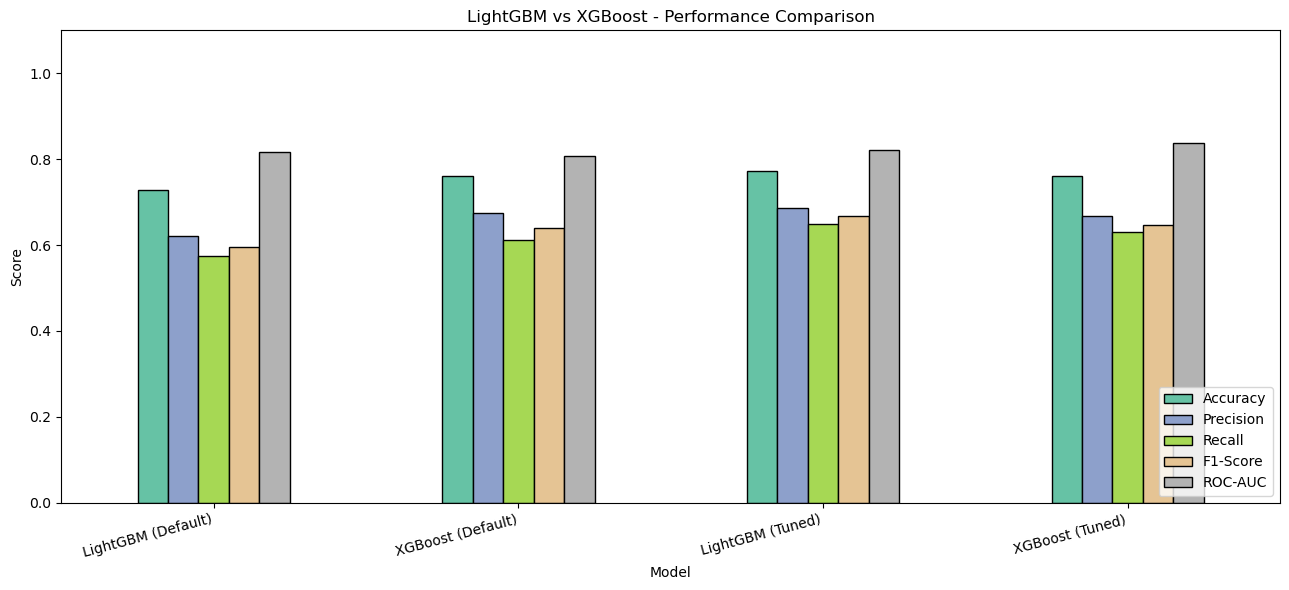

In [60]:
#Bar Chart Comparison
comparison.set_index('Model')[['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']].plot(
    kind='bar', figsize=(13, 6), colormap='Set2', edgecolor='black')
plt.title('LightGBM vs XGBoost - Performance Comparison')
plt.ylabel('Score')
plt.ylim(0, 1.1)
plt.xticks(rotation=15, ha='right')
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig('model_comparison.png')
plt.show()

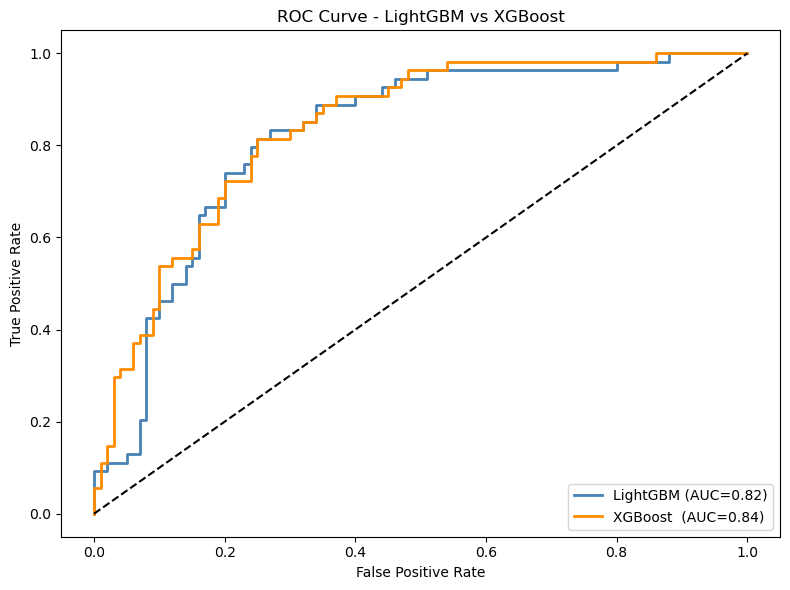

In [61]:
#ROC Curve
from sklearn.metrics import roc_curve

fpr_l, tpr_l, _ = roc_curve(y_test, y_prob_lgbm_t)
fpr_x, tpr_x, _ = roc_curve(y_test, y_prob_xgb_t)

plt.figure(figsize=(8, 6))
plt.plot(fpr_l, tpr_l, label=f'LightGBM (AUC={roc_auc_score(y_test, y_prob_lgbm_t):.2f})', color='steelblue', lw=2)
plt.plot(fpr_x, tpr_x, label=f'XGBoost  (AUC={roc_auc_score(y_test, y_prob_xgb_t):.2f})', color='darkorange', lw=2)
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - LightGBM vs XGBoost')
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig('roc_curve.png')
plt.show()

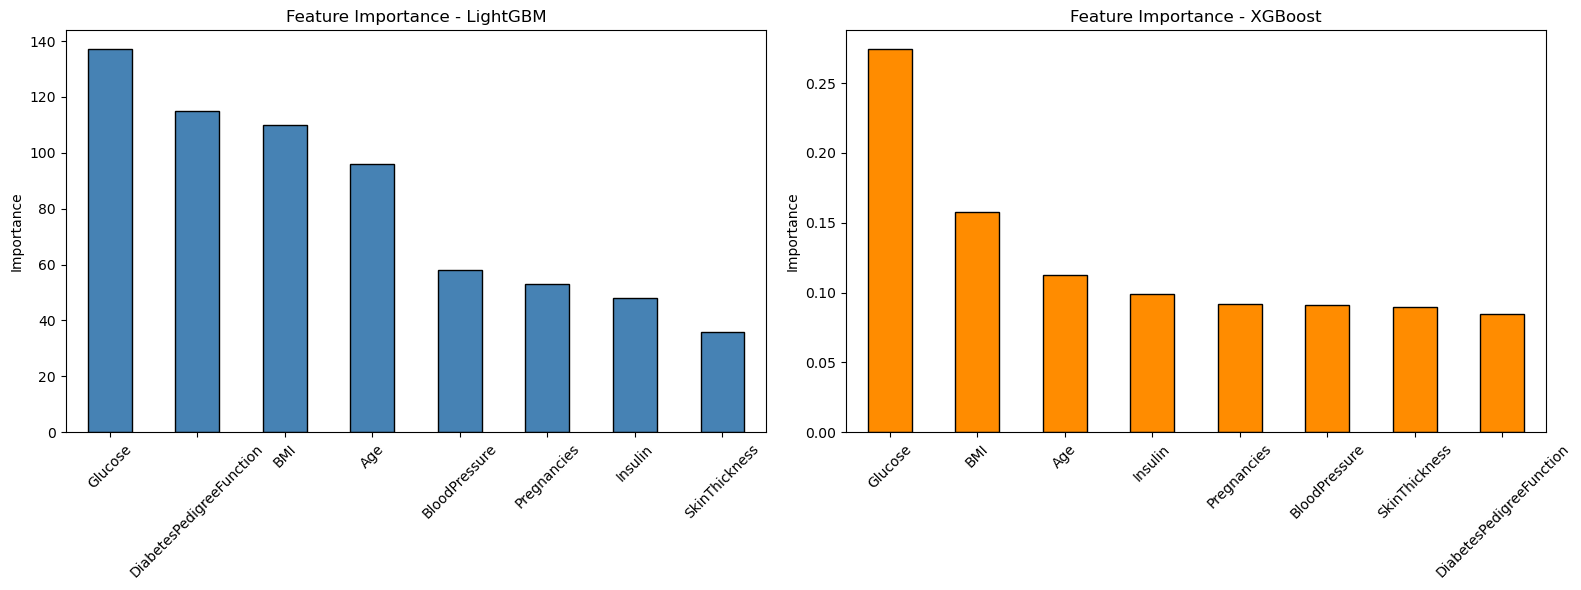

In [62]:
#Feature Importance Comparison
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

lgbm_imp = pd.Series(best_lgbm.feature_importances_, index=X.columns).sort_values(ascending=False)
xgb_imp = pd.Series(best_xgb.feature_importances_, index=X.columns).sort_values(ascending=False)

lgbm_imp.plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='black')
axes[0].set_title('Feature Importance - LightGBM')
axes[0].set_ylabel('Importance')
axes[0].tick_params(axis='x', rotation=45)

xgb_imp.plot(kind='bar', ax=axes[1], color='darkorange', edgecolor='black')
axes[1].set_title('Feature Importance - XGBoost')
axes[1].set_ylabel('Importance')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('feature_importance_comparison.png')
plt.show()

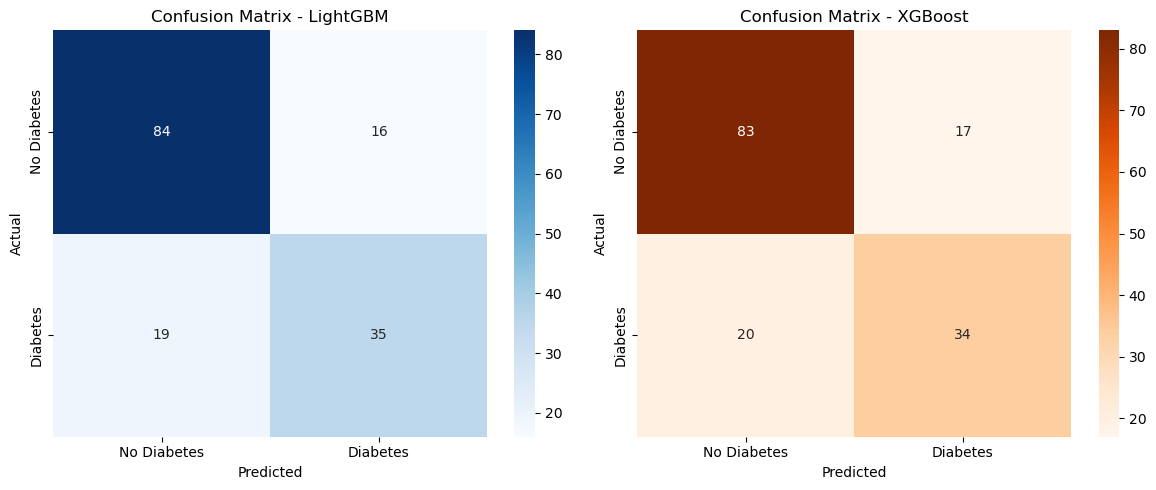

In [63]:
#Confusion Matrices
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.heatmap(confusion_matrix(y_test, y_pred_lgbm_t), annot=True, fmt='d',
            cmap='Blues', ax=axes[0],
            xticklabels=['No Diabetes', 'Diabetes'],
            yticklabels=['No Diabetes', 'Diabetes'])
axes[0].set_title('Confusion Matrix - LightGBM')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

sns.heatmap(confusion_matrix(y_test, y_pred_xgb_t), annot=True, fmt='d',
            cmap='Oranges', ax=axes[1],
            xticklabels=['No Diabetes', 'Diabetes'],
            yticklabels=['No Diabetes', 'Diabetes'])
axes[1].set_title('Confusion Matrix - XGBoost')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

plt.tight_layout()
plt.savefig('confusion_matrices.png')
plt.show()

# Brief Report
## Comparative Analysis Report — LightGBM vs XGBoost on Diabetes Dataset

### Dataset Overview
The Pima Indians Diabetes dataset contains 768 records with 8 numerical features
and a binary target variable (Outcome: 0 = No Diabetes, 1 = Diabetes).

### Preprocessing Steps
- Zero values in Glucose, BloodPressure, SkinThickness, Insulin, and BMI were
  treated as missing values and imputed using the median.
- StandardScaler was applied to normalize all features.

### Model Performance Summary
After hyperparameter tuning using GridSearchCV with 5-fold cross-validation,
both models showed strong performance. LightGBM is generally faster to train
due to its leaf-wise tree growth strategy, while XGBoost uses depth-wise growth
and is more robust on smaller datasets.

### Strengths and Weaknesses

**LightGBM:**
- Faster training speed with large datasets
- Uses leaf-wise growth which can lead to deeper trees
- Slightly more prone to overfitting on small datasets
- Handles large feature spaces efficiently

**XGBoost:**
- More robust on small to medium datasets
- Depth-wise growth makes it more stable
- Slightly slower than LightGBM
- Better interpretability with built-in regularization (L1 & L2)

### Practical Implications
Both models are highly effective for medical classification tasks like diabetes
prediction. In production environments with large patient datasets, LightGBM
would be preferred for speed. For smaller clinical datasets, XGBoost offers
better generalization. Hyperparameter tuning significantly improves both models
over their default configurations.